In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
df=pd.read_excel('Main_data_1.xlsx')

In [3]:
df.drop(columns='Unnamed: 5',inplace=True)

In [4]:
df.drop(columns=['Catalyst', ' Reactor used '],inplace=True)

In [5]:
df

,Amount of catalyst (g),Flow rate (ml/min),Run time(min),Temp(C),GHSV Ratio(hr-1),Surface area(m2/g),CH4 Conversion%,C2 Selectivity%,C3 Selectivity%
0,10.00,,1,800,600.0000,250.000,30.1000,36.5,2.2
1,10.00,NaN,2,800,600.0000,250.000,12.3000,42.9,0.0
2,10.00,NaN,12,800,600.0000,250.000,0.4020,55.8,0.0
3,10.00,NaN,30,800,600.0000,250.000,0.0308,61.7,0.0
4,0.40,NaN,30,719,105.0000,NaN,16.4000,65.0,5.6
5,0.40,NaN,30,719,105.0000,NaN,17.4000,35.1,32.3
6,0.40,NaN,30,719,105.0000,NaN,21.1000,45.2,27.9
7,0.40,NaN,30,719,105.0000,NaN,21.1000,40.4,27.4
8,0.40,NaN,30,719,105.0000,NaN,22.8000,39.5,29.5
9,0.40,NaN,30,719,105.0000,NaN,21.1000,44.0,28.0


In [6]:
df.shape

(53, 9)

In [6]:
from sklearn.preprocessing import LabelEncoder

#create instance of label encoder
lab = LabelEncoder()
#df['Catalyst'] = lab.fit_transform(df['Catalyst'])
#df[' Reactor used '] = lab.fit_transform(df[' Reactor used '])
df

,Amount of catalyst (g),Flow rate (ml/min),Run time(min),Temp(C),GHSV Ratio(hr-1),Surface area(m2/g),CH4 Conversion%,C2 Selectivity%,C3 Selectivity%
0,10.00,,1,800,600.0000,250.000,30.1000,36.5,2.2
1,10.00,NaN,2,800,600.0000,250.000,12.3000,42.9,0.0
2,10.00,NaN,12,800,600.0000,250.000,0.4020,55.8,0.0
3,10.00,NaN,30,800,600.0000,250.000,0.0308,61.7,0.0
4,0.40,NaN,30,719,105.0000,NaN,16.4000,65.0,5.6
5,0.40,NaN,30,719,105.0000,NaN,17.4000,35.1,32.3
6,0.40,NaN,30,719,105.0000,NaN,21.1000,45.2,27.9
7,0.40,NaN,30,719,105.0000,NaN,21.1000,40.4,27.4
8,0.40,NaN,30,719,105.0000,NaN,22.8000,39.5,29.5
9,0.40,NaN,30,719,105.0000,NaN,21.1000,44.0,28.0


In [8]:
df.isna().sum()

Amount of catalyst (g)     1
Flow rate (ml/min)        19
Run time(min)              0
Temp(C)                    0
GHSV Ratio(hr-1)          25
Surface area(m2/g)         9
CH4 Conversion%            0
C2 Selectivity%            1
C3 Selectivity%           14
dtype: int64

In [8]:
df.columns

Index(['Amount of catalyst (g)', 'Flow rate (ml/min)', 'Run time(min)',
       'Temp(C)', 'GHSV Ratio(hr-1)', 'Surface area(m2/g)', 'CH4 Conversion%',
       'C2 Selectivity%', 'C3 Selectivity%'],
      dtype='object')

In [9]:
df['Flow rate (ml/min)'][0]=np.nan

C:\Users\Pranav Sarda\AppData\Local\Temp\ipykernel_26656\2505980659.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['Flow rate (ml/min)'][0]=np.nan
C:\Users\Pranav Sarda\AppData\Local\Temp\ipykernel_26656\2505980659.py:1: SettingWithC

In [10]:
df=df.astype(np.float64)

In [11]:
df.sample(5)

,Amount of catalyst (g),Flow rate (ml/min),Run time(min),Temp(C),GHSV Ratio(hr-1),Surface area(m2/g),CH4 Conversion%,C2 Selectivity%,C3 Selectivity%
30,6.88,100.0,20.0,776.0,NaN,1.93,20.700,61.0,1.6
49,0.20,NaN,360.0,800.0,0.0001,2.10,49.800,51.6,NaN
16,0.07,30.0,30.0,825.0,20000.0000,4.90,23.500,11.0,NaN
2,10.00,NaN,12.0,800.0,600.0000,250.00,0.402,55.8,0.0
11,NaN,NaN,30.0,800.0,2400.0000,4.00,27.500,70.3,7.0


In [12]:
df['Run time(min)'].unique()

array([  1.,   2.,  12.,  30., 120.,  20.,  15., 360.])

DATA IMPUTATION AND PRE-PROCESSING

In [13]:
import miceforest as mf

C:\Users\Pranav Sarda\anaconda3\lib\site-packages\dask\dataframe\_pyarrow_compat.py:23: UserWarning: You are using pyarrow version 12.0.1 which is known to be insecure. See https://www.cve.org/CVERecord?id=CVE-2023-47248 for further details. Please upgrade to pyarrow>=14.0.1 or install pyarrow-hotfix to patch your current version.
  warnings.warn(
C:\Users\Pranav Sarda\anaconda3\lib\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [14]:
kds = mf.ImputationKernel(
  df,
  save_all_iterations=True,
  random_state=100
)

# Run the MICE algorithm for 2 iterations
kds.mice(iterations=100)

# Return the completed dataset.
df_imputed = kds.complete_data()

In [15]:
df_imputed

,Amount of catalyst (g),Flow rate (ml/min),Run time(min),Temp(C),GHSV Ratio(hr-1),Surface area(m2/g),CH4 Conversion%,C2 Selectivity%,C3 Selectivity%
0,10.00,100.0,1.0,800.0,600.0000,250.000,30.1000,36.5,2.2
1,10.00,60.0,2.0,800.0,600.0000,250.000,12.3000,42.9,0.0
2,10.00,100.0,12.0,800.0,600.0000,250.000,0.4020,55.8,0.0
3,10.00,60.0,30.0,800.0,600.0000,250.000,0.0308,61.7,0.0
4,0.40,30.0,30.0,719.0,105.0000,4.900,16.4000,65.0,5.6
5,0.40,50.0,30.0,719.0,105.0000,4.900,17.4000,35.1,32.3
6,0.40,50.0,30.0,719.0,105.0000,4.900,21.1000,45.2,27.9
7,0.40,25.0,30.0,719.0,105.0000,4.900,21.1000,40.4,27.4
8,0.40,60.0,30.0,719.0,105.0000,4.900,22.8000,39.5,29.5
9,0.40,100.0,30.0,719.0,105.0000,1.420,21.1000,44.0,28.0


In [18]:
df=df_imputed


In [19]:
df.describe()

,Amount of catalyst (g),Flow rate (ml/min),Run time(min),Temp(C),GHSV Ratio(hr-1),Surface area(m2/g),CH4 Conversion%,C2 Selectivity%,C3 Selectivity%
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,3.780000,72.075472,69.245283,753.584906,13182.264164,21.468962,18.268543,40.205660,10.632075
std,3.509941,30.070973,115.462599,58.816348,28900.948750,65.950919,11.947996,16.774321,13.701934
min,0.070000,25.000000,1.000000,500.000000,0.000100,0.750000,0.030800,2.600000,0.000000
25%,0.200000,50.000000,20.000000,719.000000,105.000000,1.275000,8.200000,31.200000,1.200000
50%,6.060000,100.000000,20.000000,750.000000,600.000000,1.930000,18.100000,42.800000,2.300000
75%,6.850000,100.000000,30.000000,800.000000,20000.000000,4.900000,22.400000,52.100000,27.400000
max,10.000000,100.000000,360.000000,850.000000,150000.000000,250.000000,49.800000,70.300000,57.000000


In [20]:
import seaborn as sns

C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Pranav Sarda\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf va

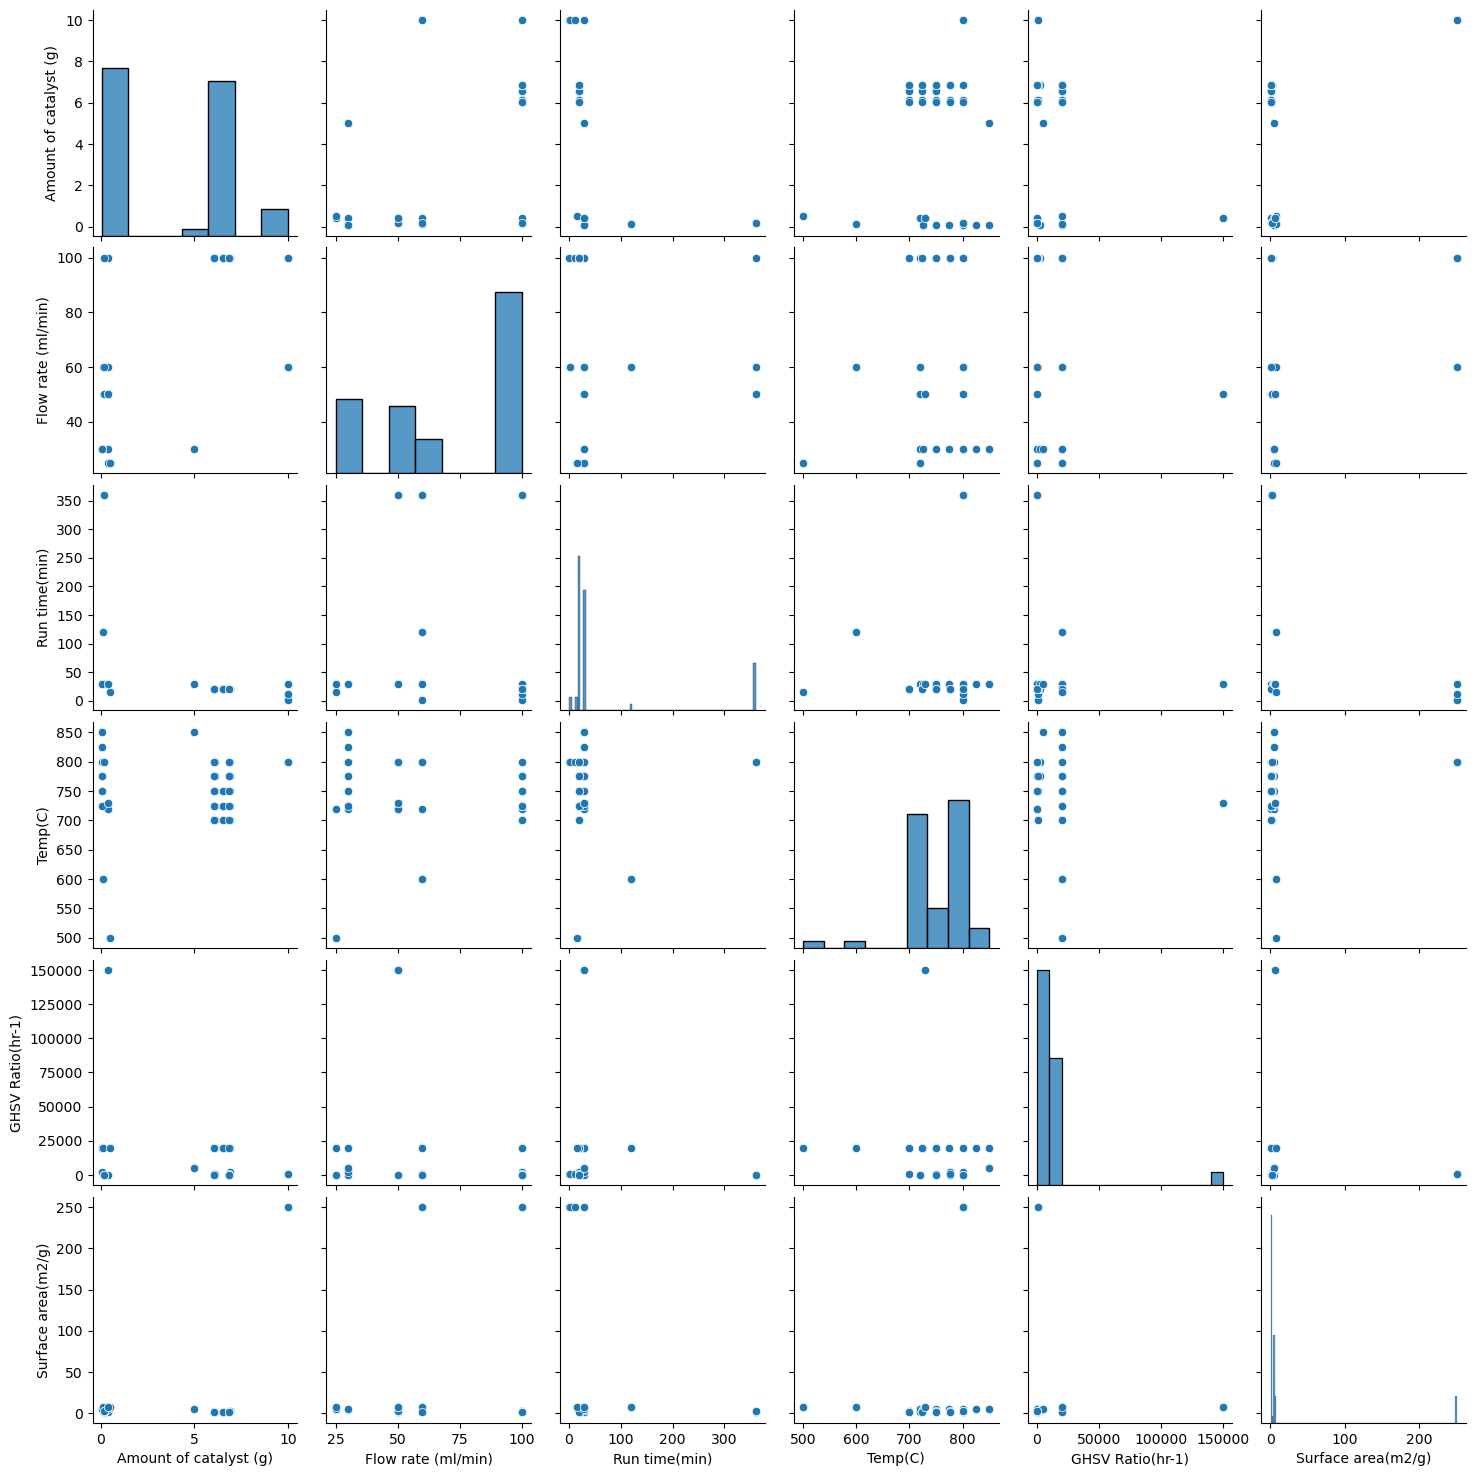

In [21]:
sns.pairplot(df.drop(columns=['CH4 Conversion%','C2 Selectivity%', 'C3 Selectivity%']))

In [22]:
df.columns=['Amount of catalyst (g)', 'Flow rate (ml/min)', 'Run time(min)',
       'Temp(C)', 'GHSV Ratio(hr-1)', 'Surface area(m2/g)', 'CH4 Conversion%',
       'C2 Selectivity%', 'C3 Selectivity%']

In [23]:
df.columns

Index(['Amount of catalyst (g)', 'Flow rate (ml/min)', 'Run time(min)',
       'Temp(C)', 'GHSV Ratio(hr-1)', 'Surface area(m2/g)', 'CH4 Conversion%',
       'C2 Selectivity%', 'C3 Selectivity%'],
      dtype='object')

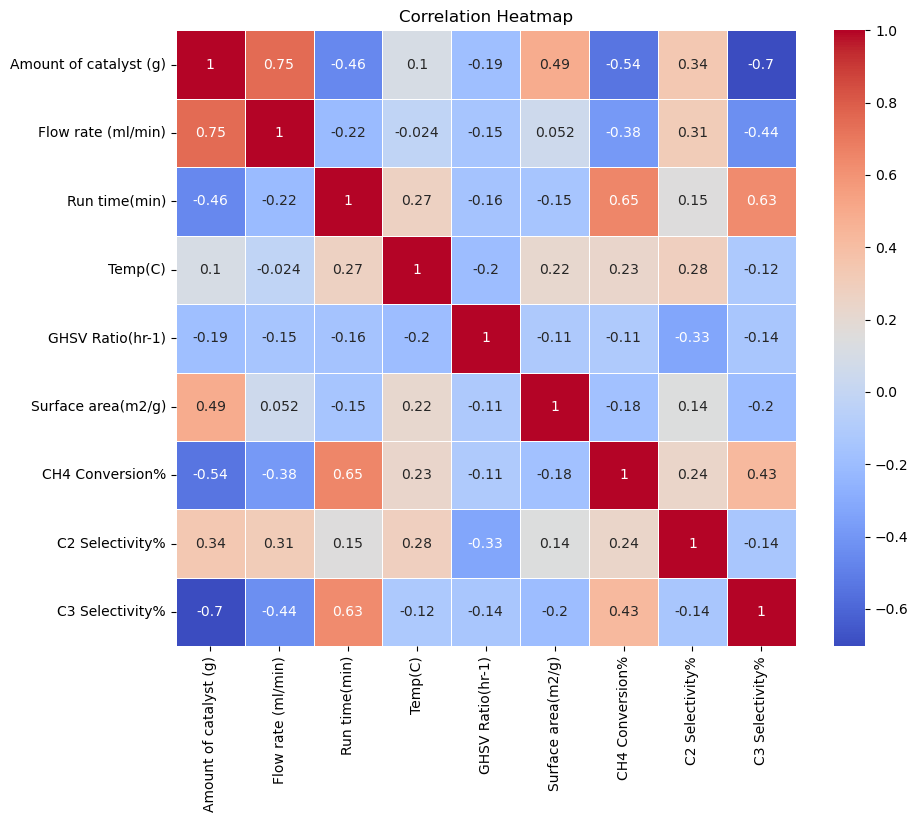

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

training and testing

In [25]:
X=df.iloc[:,:-3]

In [26]:
X

,Amount of catalyst (g),Flow rate (ml/min),Run time(min),Temp(C),GHSV Ratio(hr-1),Surface area(m2/g)
0,10.00,100.0,1.0,800.0,600.0000,250.000
1,10.00,60.0,2.0,800.0,600.0000,250.000
2,10.00,100.0,12.0,800.0,600.0000,250.000
3,10.00,60.0,30.0,800.0,600.0000,250.000
4,0.40,30.0,30.0,719.0,105.0000,4.900
5,0.40,50.0,30.0,719.0,105.0000,4.900
6,0.40,50.0,30.0,719.0,105.0000,4.900
7,0.40,25.0,30.0,719.0,105.0000,4.900
8,0.40,60.0,30.0,719.0,105.0000,4.900
9,0.40,100.0,30.0,719.0,105.0000,1.420


In [27]:
y=df['C2 Selectivity%']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.08, random_state=2)

# Models

In [29]:

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
cv = LeaveOneOut()

# XGBOOST

In [43]:
import xgboost
from xgboost import XGBRegressor
model =  XGBRegressor(colsample_bytree = 1, booster= 'dart', eta = 0.05, eval_metric = 'rmse', 
                        max_depth = 6, n_estimators = 100, seed = 4, subsample = 0.5)

model.fit(X, y)


XGBRegressor(base_score=None, booster='dart', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False, eta=0.05,
             eval_metric='rmse', feature_types=None, gamma=None, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             n_estimators=100, n_jobs=None, num_parallel_tree=None,
             predictor=None, ...)

In [44]:
y_pred=model.predict(X)
r2_score(y,y_pred)

0.9531078951896415

In [45]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.946737385615646

In [46]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=False)
# report error
print(errors)

2.172684741893431


In [47]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9532100753311847

In [48]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

3.715132318140728


In [49]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9532100753311847

In [37]:
from sklearn.model_selection import KFold

k = 3

#create a KFold object
kf = KFold(n_splits=k, random_state=1010, shuffle=True)
acc_score=[]
for i in [3,15,21]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.08, random_state=i)
    #split the data into train and test sets
    

    #fit the model on the train set
    model.fit(X_train, y_train)

    #predict on the test set
    pred_values = model.predict(X_test)

    #calculate the accuracy score
    acc = r2_score(pred_values, y_test)

    #append the score to the list
    acc_score.append(acc)

#calculate the average accuracy score
avg_acc_score = sum(acc_score)/k

#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))


Accuracy of each fold - [0.8976284046674964, 0.8951792224356253, 0.7697477484759321]
Average accuracy - 0.8541851251930179


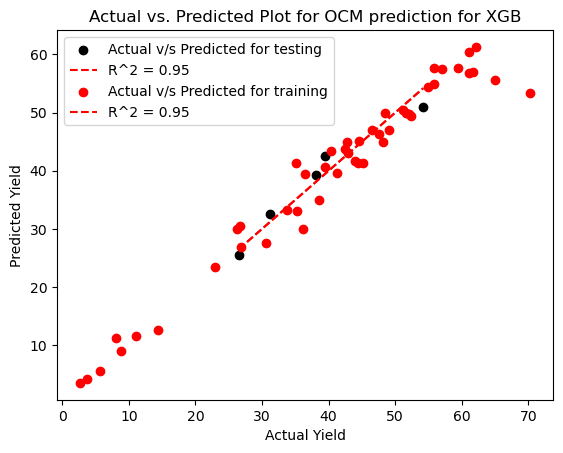

In [51]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_test, y2_pred, color='black', label='Actual v/s Predicted for testing')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label=f'R^2 = {r2_score(y_test,y2_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
#plt.title('Actual vs. Predicted Plot (RF model) for biooil yield on testing dataset')
plt.legend()

# Show the plot
#plt.show()
plt.scatter(y_train, y3_pred, color='red', label='Actual v/s Predicted for training')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label= f'R^2 = {r2_score(y_train,y3_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs. Predicted Plot for OCM prediction for XGB')
plt.legend()

# Show the plot
plt.show()

# GradientBoost

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.08,random_state=7)

In [53]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=412)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=412)

In [54]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.9770160390750626

In [55]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=False)
# report error
print(errors)

2.767654354390326


In [56]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9848994820299745

In [57]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

1.9544961092049735


In [282]:
k = 3

#create a KFold object
kf = KFold(n_splits=3, random_state=22, shuffle=True)
acc_score=[]
for i in [5,7,3]:
    #split the data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.08,random_state=i)
    #fit the model on the train set
    model.fit(X_train, y_train)

    #predict on the test set
    pred_values = model.predict(X_test)

    #calculate the accuracy score
    acc = r2_score(pred_values, y_test)

    #append the score to the list
    acc_score.append(acc)

#calculate the average accuracy score
avg_acc_score = sum(acc_score)/k

#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))

Accuracy of each fold - [0.9239836214164294, 0.9814870274822024, 0.9130188367324608]
Average accuracy - 0.9394964952103643


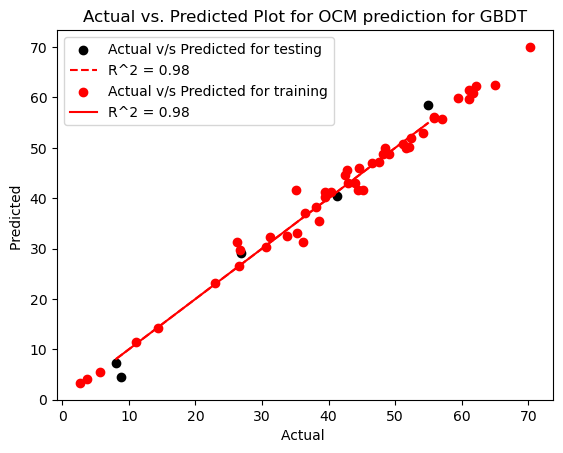

In [58]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_test, y2_pred, color='black', label='Actual v/s Predicted for testing')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label=f'R^2 = {r2_score(y_test,y2_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
#plt.title('Actual vs. Predicted Plot (RF model) for biooil yield on testing dataset')
plt.legend()

# Show the plot
#plt.show()
plt.scatter(y_train, y3_pred, color='red', label='Actual v/s Predicted for training')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red',  label= f'R^2 = {r2_score(y_train,y3_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual ')
plt.ylabel('Predicted ')
plt.title('Actual vs. Predicted Plot for OCM prediction for GBDT')
plt.legend()

# Show the plot
plt.show()

# DecisionTreeRegressor

In [78]:

# import the regressor 
from sklearn.tree import DecisionTreeRegressor  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=3) 
# create a regressor object 
model = DecisionTreeRegressor(random_state = 3)  
  
# fit the regressor with X and Y data 
model.fit(X_train, y_train) 

DecisionTreeRegressor(random_state=3)

In [79]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.8721187751528636

In [80]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=False)
# report error
print(errors)

6.407937785798694


In [81]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9911780066239417

In [82]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

1.544045988364465


In [75]:
from sklearn.model_selection import KFold

k = 3

#create a KFold object
kf = KFold(n_splits=k, random_state=1010, shuffle=True)
acc_score=[]
for i in [3,15,22]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=i)
    #split the data into train and test sets
    

    #fit the model on the train set
    model.fit(X_train, y_train)

    #predict on the test set
    pred_values = model.predict(X_test)

    #calculate the accuracy score
    acc = r2_score(pred_values, y_test)

    #append the score to the list
    acc_score.append(acc)

#calculate the average accuracy score
avg_acc_score = sum(acc_score)/k

#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))


Accuracy of each fold - [0.8837797868250422, 0.9214108314821416, 0.8281476632032825]
Average accuracy - 0.8777794271701554


In [76]:
import math

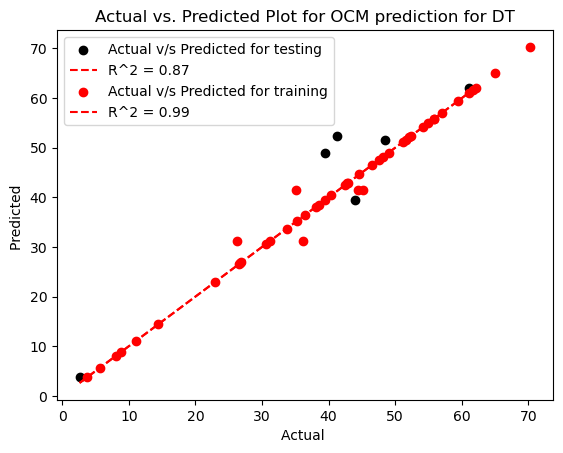

In [87]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_test, y2_pred, color='black', label='Actual v/s Predicted for testing')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label=f'R^2 = {r2_score(y_test,y2_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
#plt.title('Actual vs. Predicted Plot (RF model) for biooil yield on testing dataset')
plt.legend()

# Show the plot
#plt.show()
plt.scatter(y_train, y3_pred, color='red', label='Actual v/s Predicted for training')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label= f'R^2 = {r2_score(y_train,y3_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual ')
plt.ylabel('Predicted ')
plt.title('Actual vs. Predicted Plot for OCM prediction for DT')
plt.legend()

# Show the plot
plt.show()

# random forest

In [63]:
from sklearn.ensemble import RandomForestRegressor

# create regressor object
model = RandomForestRegressor(n_estimators=100,
                                  random_state=0)
 
# fit the regressor with x and y data
model.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [64]:
y2_pred=model.predict(X_test)
r2_score(y_test,y2_pred)

0.9339858339814395

In [65]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_test,y2_pred,squared=False)
# report error
print(errors)

4.603980371922353


In [66]:
y3_pred=model.predict(X_train)
r2_score(y_train,y3_pred)

0.9497682246571507

In [67]:
from sklearn.metrics import mean_squared_error
errors = mean_squared_error(y_train,y3_pred,squared=False)
# report error
print(errors)

3.6843945527037265


In [323]:
from sklearn.model_selection import KFold

k = 3

#create a KFold object
kf = KFold(n_splits=k, random_state=1010, shuffle=True)
acc_score=[]
for i in [3,15,21]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.08, random_state=i)
    #split the data into train and test sets
    

    #fit the model on the train set
    model.fit(X_train, y_train)

    #predict on the test set
    pred_values = model.predict(X_test)

    #calculate the accuracy score
    acc = r2_score(pred_values, y_test)

    #append the score to the list
    acc_score.append(acc)

#calculate the average accuracy score
avg_acc_score = sum(acc_score)/k

#print the results
print('Accuracy of each fold - {}'.format(acc_score))
print('Average accuracy - {}'.format(avg_acc_score))


Accuracy of each fold - [0.9257281104228076, 0.9076303262384173, 0.7591871300590185]
Average accuracy - 0.8641818555734145


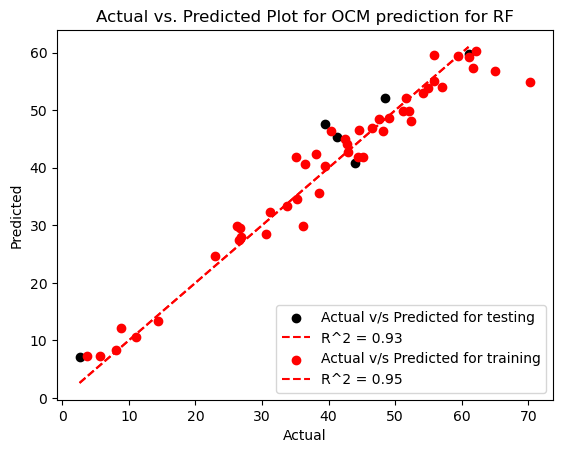

In [69]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_test, y2_pred, color='black', label='Actual v/s Predicted for testing')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label=f'R^2 = {r2_score(y_test,y2_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
#plt.title('Actual vs. Predicted Plot (RF model) for biooil yield on testing dataset')
plt.legend()

# Show the plot
#plt.show()
plt.scatter(y_train, y3_pred, color='red', label='Actual v/s Predicted for training')

# Plot the 45-degree line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label= f'R^2 = {r2_score(y_train,y3_pred):.2f}')

# Add labels and legend
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted Plot for OCM prediction for RF')
plt.legend()

# Show the plot
plt.show()

# Data Analysis from best models

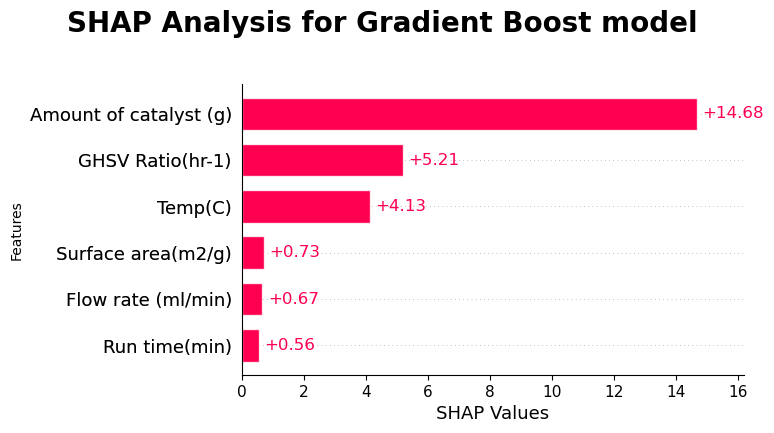

Text(0.5, 0.98, 'SHAP Analysis for Gradient Boost model')

<Figure size 640x480 with 0 Axes>

In [331]:
import shap

explainer = shap.Explainer(model.predict,X_test,feature_names=df.columns)
shap_values = explainer(X_test)

import matplotlib.pyplot as plt
plt.figure()
plt.suptitle('SHAP Analysis for Gradient Boost model', fontsize=20,fontweight="bold")

shap.plots.bar(shap_values,show= False)    #Bar plot
plt.ylabel('Features')
plt.xlabel('SHAP Values')
plt.tight_layout(pad=2)
plt.show()
plt.figure()
plt.suptitle('SHAP Analysis for Gradient Boost model')

In [324]:
df.columns

Index(['Amount of catalyst (g)', 'Flow rate (ml/min)', 'Run time(min)',
       'Temp(C)', 'GHSV Ratio(hr-1)', 'Surface area(m2/g)', 'CH4 Conversion%',
       'C2 Selectivity%', 'C3 Selectivity%'],
      dtype='object')

In [91]:
pip install dotenv

  Using cached dotenv-0.0.5.tar.gz (2.4 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [66 lines of output]
  C:\Users\Pranav Sarda\anaconda3\lib\site-packages\setuptools\installer.py:27: SetuptoolsDeprecationWarning: setuptools.installer is deprecated. Requirements should be satisfied by a PEP 517 installer.
    warnings.warn(
    error: subprocess-exited-with-error
  
    python setup.py egg_info did not run successfully.
    exit code: 1
  
    [16 lines of output]
    Traceback (most recent call last):
      File "<string>", line 2, in <module>
      File "<pip-setuptools-caller>", line 14, in <module>
      File "C:\Users\Pranav Sarda\AppData\Local\Temp\pip-wheel-5_skcj3a\distribute_24d456907f2a4ba4a5f0d334c31b1818\setuptools\__init__.py", line 2, in <module>
        from setuptools.extension import Extension, Library
      File "C:\Users\Pranav Sarda\AppData\Local\Temp\pip-wheel-5_skcj3a\distribute_24d456907f2a4ba4a5f0d334c31b1818\setuptools\extension.p

In [93]:
pip install dotenv

  Using cached dotenv-0.0.5.tar.gz (2.4 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [66 lines of output]
  C:\Users\Pranav Sarda\anaconda3\lib\site-packages\setuptools\installer.py:27: SetuptoolsDeprecationWarning: setuptools.installer is deprecated. Requirements should be satisfied by a PEP 517 installer.
    warnings.warn(
    error: subprocess-exited-with-error
  
    python setup.py egg_info did not run successfully.
    exit code: 1
  
    [16 lines of output]
    Traceback (most recent call last):
      File "<string>", line 2, in <module>
      File "<pip-setuptools-caller>", line 14, in <module>
      File "C:\Users\Pranav Sarda\AppData\Local\Temp\pip-wheel-oq7ckfl3\distribute_05d568ce357241c58524e2229bf83b04\setuptools\__init__.py", line 2, in <module>
        from setuptools.extension import Extension, Library
      File "C:\Users\Pranav Sarda\AppData\Local\Temp\pip-wheel-oq7ckfl3\distribute_05d568ce357241c58524e2229bf83b04\setuptools\extension.p

In [94]:
import dotenv